In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import os

In [2]:
# Create 1000 hourly timestamps
dates = pd.date_range(start="2023-01-01", periods=1000, freq="h")

df = pd.DataFrame({"datetime": dates})

# Time features
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month
df["day_of_year"] = df["datetime"].dt.dayofyear

# Base consumption
base_load = 1.5

# Evening peak pattern
evening_peak = 2 * np.sin((df["hour"] - 18) * np.pi / 12)

# Weekend boost
weekend_effect = np.where(df["weekday"] >= 5, 0.5, 0)

# Random noise
noise = np.random.normal(0, 0.3, size=len(df))

df["energy_usage_kWh"] = base_load + evening_peak + weekend_effect + noise

df.head()

,datetime,hour,weekday,month,day_of_year,energy_usage_kWh
0,2023-01-01 00:00:00,0,6,1,1,4.188845
1,2023-01-01 01:00:00,1,6,1,1,3.627289
2,2023-01-01 02:00:00,2,6,1,1,4.215009
3,2023-01-01 03:00:00,3,6,1,1,3.455921
4,2023-01-01 04:00:00,4,6,1,1,3.233879


In [5]:
# Ensure directory exists
os.makedirs("../data/raw", exist_ok=True)

# Save CSV
df[["datetime", "energy_usage_kWh"]].to_csv(
    "../data/raw/synthetic_energy_data.csv",
    index=False
)

print("Synthetic dataset saved successfully!")

Synthetic dataset saved successfully!


In [3]:
# Create 1000 hourly timestamps
dates = pd.date_range(start="2023-01-01", periods=1000, freq="h")

df = pd.DataFrame({"datetime": dates})

# Time features
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month
df["day_of_year"] = df["datetime"].dt.dayofyear

# Base consumption
base_load = 1.5

# Evening peak pattern
evening_peak = 2 * np.sin((df["hour"] - 18) * np.pi / 12)

# Weekend boost
weekend_effect = np.where(df["weekday"] >= 5, 0.5, 0)

# Random noise
noise = np.random.normal(0, 0.3, size=len(df))

df["energy_usage_kWh"] = base_load + evening_peak + weekend_effect + noise

df.head()

,datetime,hour,weekday,month,day_of_year,energy_usage_kWh
0,2023-01-01 00:00:00,0,6,1,1,3.667889
1,2023-01-01 01:00:00,1,6,1,1,3.846997
2,2023-01-01 02:00:00,2,6,1,1,3.984937
3,2023-01-01 03:00:00,3,6,1,1,3.495302
4,2023-01-01 04:00:00,4,6,1,1,2.854459


In [4]:
# Create lag features
df["lag_1"] = df["energy_usage_kWh"].shift(1)
df["lag_24"] = df["energy_usage_kWh"].shift(24)

# Rolling features
df["rolling_mean_3"] = df["energy_usage_kWh"].rolling(3).mean()
df["rolling_mean_24"] = df["energy_usage_kWh"].rolling(24).mean()

# Drop NaN values from lag creation
df = df.dropna()

df.head()

,datetime,hour,weekday,month,day_of_year,energy_usage_kWh,lag_1,lag_24,rolling_mean_3,rolling_mean_24
24,2023-01-02 00:00:00,0,0,1,2,3.897845,3.570230,3.667889,3.740801,2.031996
25,2023-01-02 01:00:00,1,0,1,2,3.773679,3.897845,3.846997,3.747251,2.028941
26,2023-01-02 02:00:00,2,0,1,2,3.218786,3.773679,3.984937,3.630103,1.997018
27,2023-01-02 03:00:00,3,0,1,2,2.863196,3.218786,3.495302,3.285220,1.970680
28,2023-01-02 04:00:00,4,0,1,2,2.415935,2.863196,2.854459,2.832639,1.952409


In [6]:
features = [
    "hour",
    "weekday",
    "month",
    "day_of_year",
    "lag_1",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_24"
]

X = df[features]
y = df["energy_usage_kWh"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (976, 8)
Target shape: (976,)


In [7]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (780, 8)
Test size: (196, 8)


In [8]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [9]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.22119113495731293
RMSE: 0.27796235168106137
R2: 0.9638234815837712


In [10]:
results = pd.DataFrame({
    "datetime": df["datetime"].iloc[split:],
    "actual": y_test.values,
    "predicted": y_pred
})

results["error"] = abs(results["actual"] - results["predicted"])

threshold = results["error"].mean() + 2 * results["error"].std()

results["anomaly"] = results["error"] > threshold

print("Total anomalies detected:", results["anomaly"].sum())

Total anomalies detected: 8


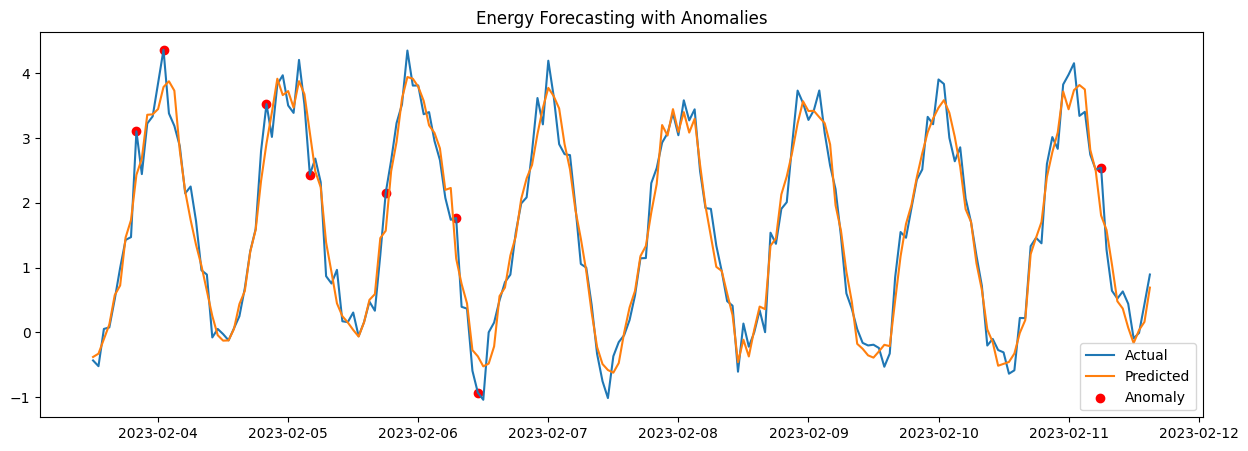

In [11]:
plt.figure(figsize=(15,5))

plt.plot(results["datetime"], results["actual"], label="Actual")
plt.plot(results["datetime"], results["predicted"], label="Predicted")

anomalies = results[results["anomaly"] == True]
plt.scatter(anomalies["datetime"], anomalies["actual"], color="red", label="Anomaly")

plt.legend()
plt.title("Energy Forecasting with Anomalies")
plt.show()

In [12]:
tariff_rate = 6  # ₹ per kWh

results["actual_cost"] = results["actual"] * tariff_rate
results["predicted_cost"] = results["predicted"] * tariff_rate

results.head()

,datetime,actual,predicted,error,anomaly,actual_cost,predicted_cost
804,2023-02-03 12:00:00,-0.434632,-0.380994,0.053638,False,-2.607795,-2.285965
805,2023-02-03 13:00:00,-0.523398,-0.329946,0.193452,False,-3.140390,-1.979675
806,2023-02-03 14:00:00,0.052370,-0.105658,0.158027,False,0.314219,-0.633945
807,2023-02-03 15:00:00,0.075456,0.120008,0.044552,False,0.452737,0.720051
808,2023-02-03 16:00:00,0.511382,0.574236,0.062855,False,3.068289,3.445418


In [13]:
os.makedirs("../ml", exist_ok=True)

joblib.dump(model, "../ml/model.pkl")

print("Model saved successfully!")

Model saved successfully!
